# **Figure 1**. (a–c) Average clustering coefficient $\langle C \rangle$ and temporal evolution of (d–f) global clustering coefficient $C$, (g–i) small-world index $\omega$, and (j–l) average shortest path length $L$.

In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# === Style settings ===
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

fontsize_labels = 36
fontsize_ticks = 28
fontsize_titles = 38
fontsize_panel_labels = 34
fontsize_legend = 34
panel_spacing = 0.25
point_size_scatter = 150

# === Global simulation selector (shared across all figures) ===
SIMULATION_ID = 1
SIMULATION_IDS = [SIMULATION_ID]

# === Color map ===
color_map = {
    "0.100": 'tab:orange', "0.150": 'tab:cyan', "0.200": 'tab:purple', "0.250": 'tab:brown',
    "0.300": 'b', "0.350": 'tab:pink', "0.360": 'tab:olive', "0.370": 'tab:gray',
    "0.400": 'g', "0.450": 'tab:blue', "0.500": 'r'
}

# === Mapping from p to <k> ===
p_to_k = {
    "0.060": 18,
    "0.120": 36,
    "0.180": 54
}

# === Metrics and axis limits ===
dynamic_metrics = ["clustering", "omega", "path_length"]
metric_labels = [r"$\langle C \rangle$", r"$C$", r"$\omega$", r"$L$"]
y_limits = [
    (0.0, 0.9),   # <C>
    (0.0, 0.9),   # C
    (0.0, 10.0),  # omega
    (1.7, 3.2)    # L
]

# === Initialize figure ===
fig, axs = plt.subplots(3, 4, figsize=(30, 20))
panel_labels = [f"({chr(97+i)})" for i in range(12)]
panel_label_matrix = np.array(panel_labels).reshape(4, 3).T

# === Get epsilon values and legend once from the first file
first_folder = next(iter(p_to_k))
df_temp = pd.read_csv(os.path.join(f"results/results_p{first_folder}", "network_metrics.txt"))
epsilons_for_legend = sorted(df_temp["epsilon"].unique())
legend_handles = [
    plt.Line2D([0], [0], color=color_map[f"{eps:.3f}"], lw=2.8, label=rf"$\varepsilon={eps:.2f}$")
    for eps in epsilons_for_legend
]

# === Loop through each p folder ===
for row_idx, (p_str, k_val) in enumerate(p_to_k.items()):
    folder = f"results/results_p{p_str}"
    path = os.path.join(folder, "network_metrics.txt")
    if not os.path.exists(path):
        continue

    df = pd.read_csv(path)
    df.rename(columns={"<s>": "s_mean", "<s>_std": "s_std"}, inplace=True)
    epsilon_values = sorted(df["epsilon"].unique())
    n_last = 100000

    # Panel for <C>
    ax = axs[row_idx, 0]
    ax.set_ylim(y_limits[0])
    avg_clustering = []
    std_clustering = []

    for eps in epsilon_values:
        df_eps = df[df["epsilon"] == eps]
        max_step = df_eps["time_step"].max()
        df_final = df_eps[df_eps["time_step"] >= max_step - n_last]
        grouped = df_final.groupby("simulation")["clustering"].mean()
        avg_clustering.append(grouped.mean())
        std_clustering.append(grouped.std())

    eps_array = np.array(epsilon_values)
    colors = [color_map.get(f"{eps:.3f}", 'k') for eps in eps_array]
    ax.scatter(eps_array, avg_clustering, c=colors, s=point_size_scatter, zorder=2)
    ax.plot(eps_array, avg_clustering, color='black', linewidth=1.2, zorder=1)
    ax.errorbar(eps_array, avg_clustering, yerr=std_clustering,
                fmt='none', ecolor='black', elinewidth=2.0, capsize=3, capthick=1.5, zorder=3)

    if row_idx == 2:
        ax.set_xlabel(r"$\varepsilon$", fontsize=fontsize_labels)
    if row_idx == 0:
        ax.set_title(metric_labels[0], fontsize=fontsize_titles)

    ax.set_ylabel(rf"$\langle k \rangle = {k_val}$", fontsize=fontsize_labels)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.tick_params(axis='x', labelrotation=0)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')
    ax.text(0.02, 0.93, panel_label_matrix[row_idx, 0], transform=ax.transAxes,
            fontsize=fontsize_panel_labels, fontweight='bold', va='top', ha='left')

    # Panels for C, omega, L
    for col_offset, (metric, label, y_lim) in enumerate(zip(dynamic_metrics, metric_labels[1:], y_limits[1:]), start=1):
        ax = axs[row_idx, col_offset]
        ax.set_ylim(y_lim)

        for eps in epsilon_values:
            df_eps = df[df["epsilon"] == eps]
            grouped = df_eps.groupby("time_step")[metric].agg(['mean', 'std']).reset_index()
            eps_str = f"{eps:.3f}"
            color = color_map.get(eps_str, 'k')

            ax.plot(grouped["time_step"], grouped["mean"], color=color, label=rf"$\varepsilon={eps:.2f}$")
            ax.fill_between(grouped["time_step"],
                            grouped["mean"] - grouped["std"],
                            grouped["mean"] + grouped["std"],
                            color=color, alpha=0.2)

        if row_idx == 2:
            ax.set_xlabel("Time steps", fontsize=fontsize_labels)
        if row_idx == 0:
            ax.set_title(label, fontsize=fontsize_titles)

        ax.grid()
        ax.tick_params(axis='both', labelsize=fontsize_ticks)
        ax.tick_params(axis='x', labelrotation=0)
        for tick in ax.get_xticklabels():
            tick.set_horizontalalignment('right')
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
        ax.xaxis.get_offset_text().set_fontsize(fontsize_ticks + 2)

        ax.text(0.02, 0.93, panel_label_matrix[row_idx, col_offset], transform=ax.transAxes,
                fontsize=fontsize_panel_labels, fontweight='bold', va='top', ha='left')

# === Global legend (bottom center)
legend = fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.015),
    ncol=4,
    fontsize=fontsize_legend,
    frameon=True,
    handlelength=2.8,
    columnspacing=1.8,
    labelspacing=1.0,
    borderpad=0.7,
    handletextpad=0.8,
    alignment='center'
)
legend.get_frame().set_edgecolor('black')

# === Save output
output_dir = "plots_paper/fig1"
os.makedirs(output_dir, exist_ok=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.subplots_adjust(bottom=0.10, wspace=panel_spacing, hspace=panel_spacing)
plt.savefig(os.path.join(output_dir, "fig1.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(output_dir, "fig1.png"), dpi=300, bbox_inches="tight")
plt.close()

print("Final figure saved as plots_paper/fig1/fig1.[pdf|png]")


Final figure saved as plots_paper/fig1/fig1.[pdf|png]


# **Figure 2, 3 and 4**. Community Structure by Louvain Algorithm.

## Matrix - Graphs - States

In [26]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
SIMULATION_ID = globals().get("SIMULATION_ID", 1)
SIMULATION_IDS = globals().get("SIMULATION_IDS", [SIMULATION_ID])
k_to_p = {18: 0.060, 36: 0.120, 54: 0.180}
k_list = [18, 36, 54]
eps_list = [0.3, 0.5]
steps = (0, 10000, 100000, 300000)
ROOT = Path("results")
out_dir = Path("plots_paper/matrices_states_graphs")
out_dir.mkdir(parents=True, exist_ok=True)
STATE_CMAP = cm.autumn
STATE_NORM = plt.Normalize(vmin=-1, vmax=1)
LOUVAIN_SEED = 42
LAYOUT_SEED = 42
FIGSIZE = (42, 19)
SUPTITLE_FONTSIZE = 40
PANEL_TITLE_FONTSIZE = 26
COLORBAR_LABEL_FONTSIZE = 24
COLORBAR_TICK_FONTSIZE = 20
def _load_txt(path: Path):
    try:
        return np.loadtxt(path, delimiter=",")
    except Exception:
        return np.loadtxt(path)
def _find_state_file(base_p: Path, sim_id: int, eps_str: str, step: int):
    exact = base_p / f"simulation_{sim_id}" / "states" / f"eps_{eps_str}" / f"states_eps_{eps_str}_step_{step}.txt"
    if exact.exists():
        return exact
    return None
def _louvain_partition(A: np.ndarray):
    G = nx.from_numpy_array(A)
    part = community_louvain.best_partition(G, random_state=LOUVAIN_SEED)
    Q = community_louvain.modularity(part, G)
    return part, Q, G
def _order_by_partition_and_state(part: dict, x: np.ndarray):
    return np.array(sorted(part.keys(), key=lambda i: (part[i], x[i])), dtype=int)
def _sci_tex(n: int) -> str:
    if n == 0:
        return "0"
    s = f"{n:.0e}"
    a, b = s.split("e")
    mant = int(float(a))
    exp = int(b)
    return rf"{mant} \times 10^{{{exp}}}"
def plot_new_fig23(k: int, eps: float, sim_id: int):
    p = k_to_p[k]
    p_str = f"{p:.3f}"
    eps_str = f"{eps:.3f}"
    eps_tag = f"{eps:.3f}".rstrip("0").rstrip(".").replace(".", "_")
    base_p = ROOT / f"results_p{p_str}"
    fig = plt.figure(figsize=FIGSIZE, constrained_layout=False)
    gs = GridSpec(2, 5, figure=fig, width_ratios=[1, 1, 1, 1, 0.08], height_ratios=[1, 1])
    ax_mats = [fig.add_subplot(gs[0, i]) for i in range(4)]
    ax_graphs = [fig.add_subplot(gs[1, i]) for i in range(4)]
    cax = fig.add_subplot(gs[:, 4])
    for i, step in enumerate(steps):
        m_path = base_p / f"simulation_{sim_id}" / "networks" / f"eps_{eps_str}" / f"matrix_eps_{eps_str}_step_{step}.txt"
        s_path = _find_state_file(base_p, sim_id, eps_str, step)
        if (not m_path.exists()) or (s_path is None) or (not s_path.exists()):
            ax_mats[i].axis("off")
            ax_graphs[i].axis("off")
            ax_mats[i].text(0.5, 0.5, f"Missing data\nstep={step}", ha="center", va="center", fontsize=12)
            continue
        A = _load_txt(m_path)
        x = np.asarray(_load_txt(s_path)).reshape(-1)
        if A.ndim == 1:
            n = int(np.sqrt(A.size))
            if n * n == A.size:
                A = A.reshape(n, n)
        if x.size != A.shape[0]:
            ax_mats[i].axis("off")
            ax_graphs[i].axis("off")
            ax_mats[i].text(0.5, 0.5, f"Size mismatch\nstep={step}", ha="center", va="center", fontsize=12)
            continue
        part, Q, G = _louvain_partition(A)
        order = _order_by_partition_and_state(part, x)
        A_ord = A[np.ix_(order, order)]
        x_ord = x[order]
        axm = ax_mats[i]
        sns.heatmap(A_ord, cmap="Blues", xticklabels=False, yticklabels=False, cbar=False, ax=axm)
        axm.set_title(f"Matrix - time step = ${_sci_tex(step)}$ - Q = {Q:.3f}", fontsize=PANEL_TITLE_FONTSIZE, y=1.20, pad=4, fontstyle="normal")
        ax_top = axm.inset_axes([0.0, 1.04, 1.0, 0.05], transform=axm.transAxes)
        ax_top.imshow(x_ord.reshape(1, -1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        ax_top.set_frame_on(False)
        ax_top.set_clip_on(False)
        ax_right = axm.inset_axes([1.02, 0.0, 0.08, 1.0], transform=axm.transAxes)
        ax_right.imshow(x_ord.reshape(-1, 1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
        ax_right.set_xticks([])
        ax_right.set_yticks([])
        ax_right.set_frame_on(False)
        ax_right.set_clip_on(False)
        axg = ax_graphs[i]
        pos = nx.spring_layout(G, seed=LAYOUT_SEED)
        nx.draw_networkx_edges(G, pos, ax=axg, alpha=0.15, width=0.4)
        nx.draw_networkx_nodes(
            G,
            pos,
            ax=axg,
            node_size=45,
            node_color=x,
            cmap=STATE_CMAP,
            vmin=STATE_NORM.vmin,
            vmax=STATE_NORM.vmax,
            linewidths=0.0,
        )
        axg.set_title(f"Graph - time step = ${_sci_tex(step)}$ - Q = {Q:.3f}", fontsize=PANEL_TITLE_FONTSIZE, pad=12, fontstyle="normal")
        axg.axis("off")
    sm = cm.ScalarMappable(cmap=STATE_CMAP, norm=STATE_NORM)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Dynamic range", fontsize=COLORBAR_LABEL_FONTSIZE)
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONTSIZE)
    fig.suptitle(rf"Matrix - States and Graphs for $\langle k \rangle$ = {k}, $\varepsilon$ = {eps:.2f}, sim = {sim_id}", fontsize=SUPTITLE_FONTSIZE, y=0.992, fontstyle="normal")
    plt.subplots_adjust(top=0.78, wspace=0.26, hspace=0.34)
    out_base = out_dir / f"mgs_k{k}_p{p_str}_eps_{eps_tag}_sim_{sim_id}"
    png_file = f"{out_base}.png"
    pdf_file = f"{out_base}.pdf"
    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_file)
    plt.close(fig)
    print(f"Saved: {png_file}")
    print(f"Saved: {pdf_file}")
for sim in SIMULATION_IDS:
    for k in k_list:
        for eps in eps_list:
            plot_new_fig23(k=k, eps=eps, sim_id=sim)


Saved: plots_paper\matrices_states_graphs\mgs_k18_p0.060_eps_0_3_sim_1.png
Saved: plots_paper\matrices_states_graphs\mgs_k18_p0.060_eps_0_3_sim_1.pdf
Saved: plots_paper\matrices_states_graphs\mgs_k18_p0.060_eps_0_5_sim_1.png
Saved: plots_paper\matrices_states_graphs\mgs_k18_p0.060_eps_0_5_sim_1.pdf
Saved: plots_paper\matrices_states_graphs\mgs_k36_p0.120_eps_0_3_sim_1.png
Saved: plots_paper\matrices_states_graphs\mgs_k36_p0.120_eps_0_3_sim_1.pdf
Saved: plots_paper\matrices_states_graphs\mgs_k36_p0.120_eps_0_5_sim_1.png
Saved: plots_paper\matrices_states_graphs\mgs_k36_p0.120_eps_0_5_sim_1.pdf
Saved: plots_paper\matrices_states_graphs\mgs_k54_p0.180_eps_0_3_sim_1.png
Saved: plots_paper\matrices_states_graphs\mgs_k54_p0.180_eps_0_3_sim_1.pdf
Saved: plots_paper\matrices_states_graphs\mgs_k54_p0.180_eps_0_5_sim_1.png
Saved: plots_paper\matrices_states_graphs\mgs_k54_p0.180_eps_0_5_sim_1.pdf


## Figure 2

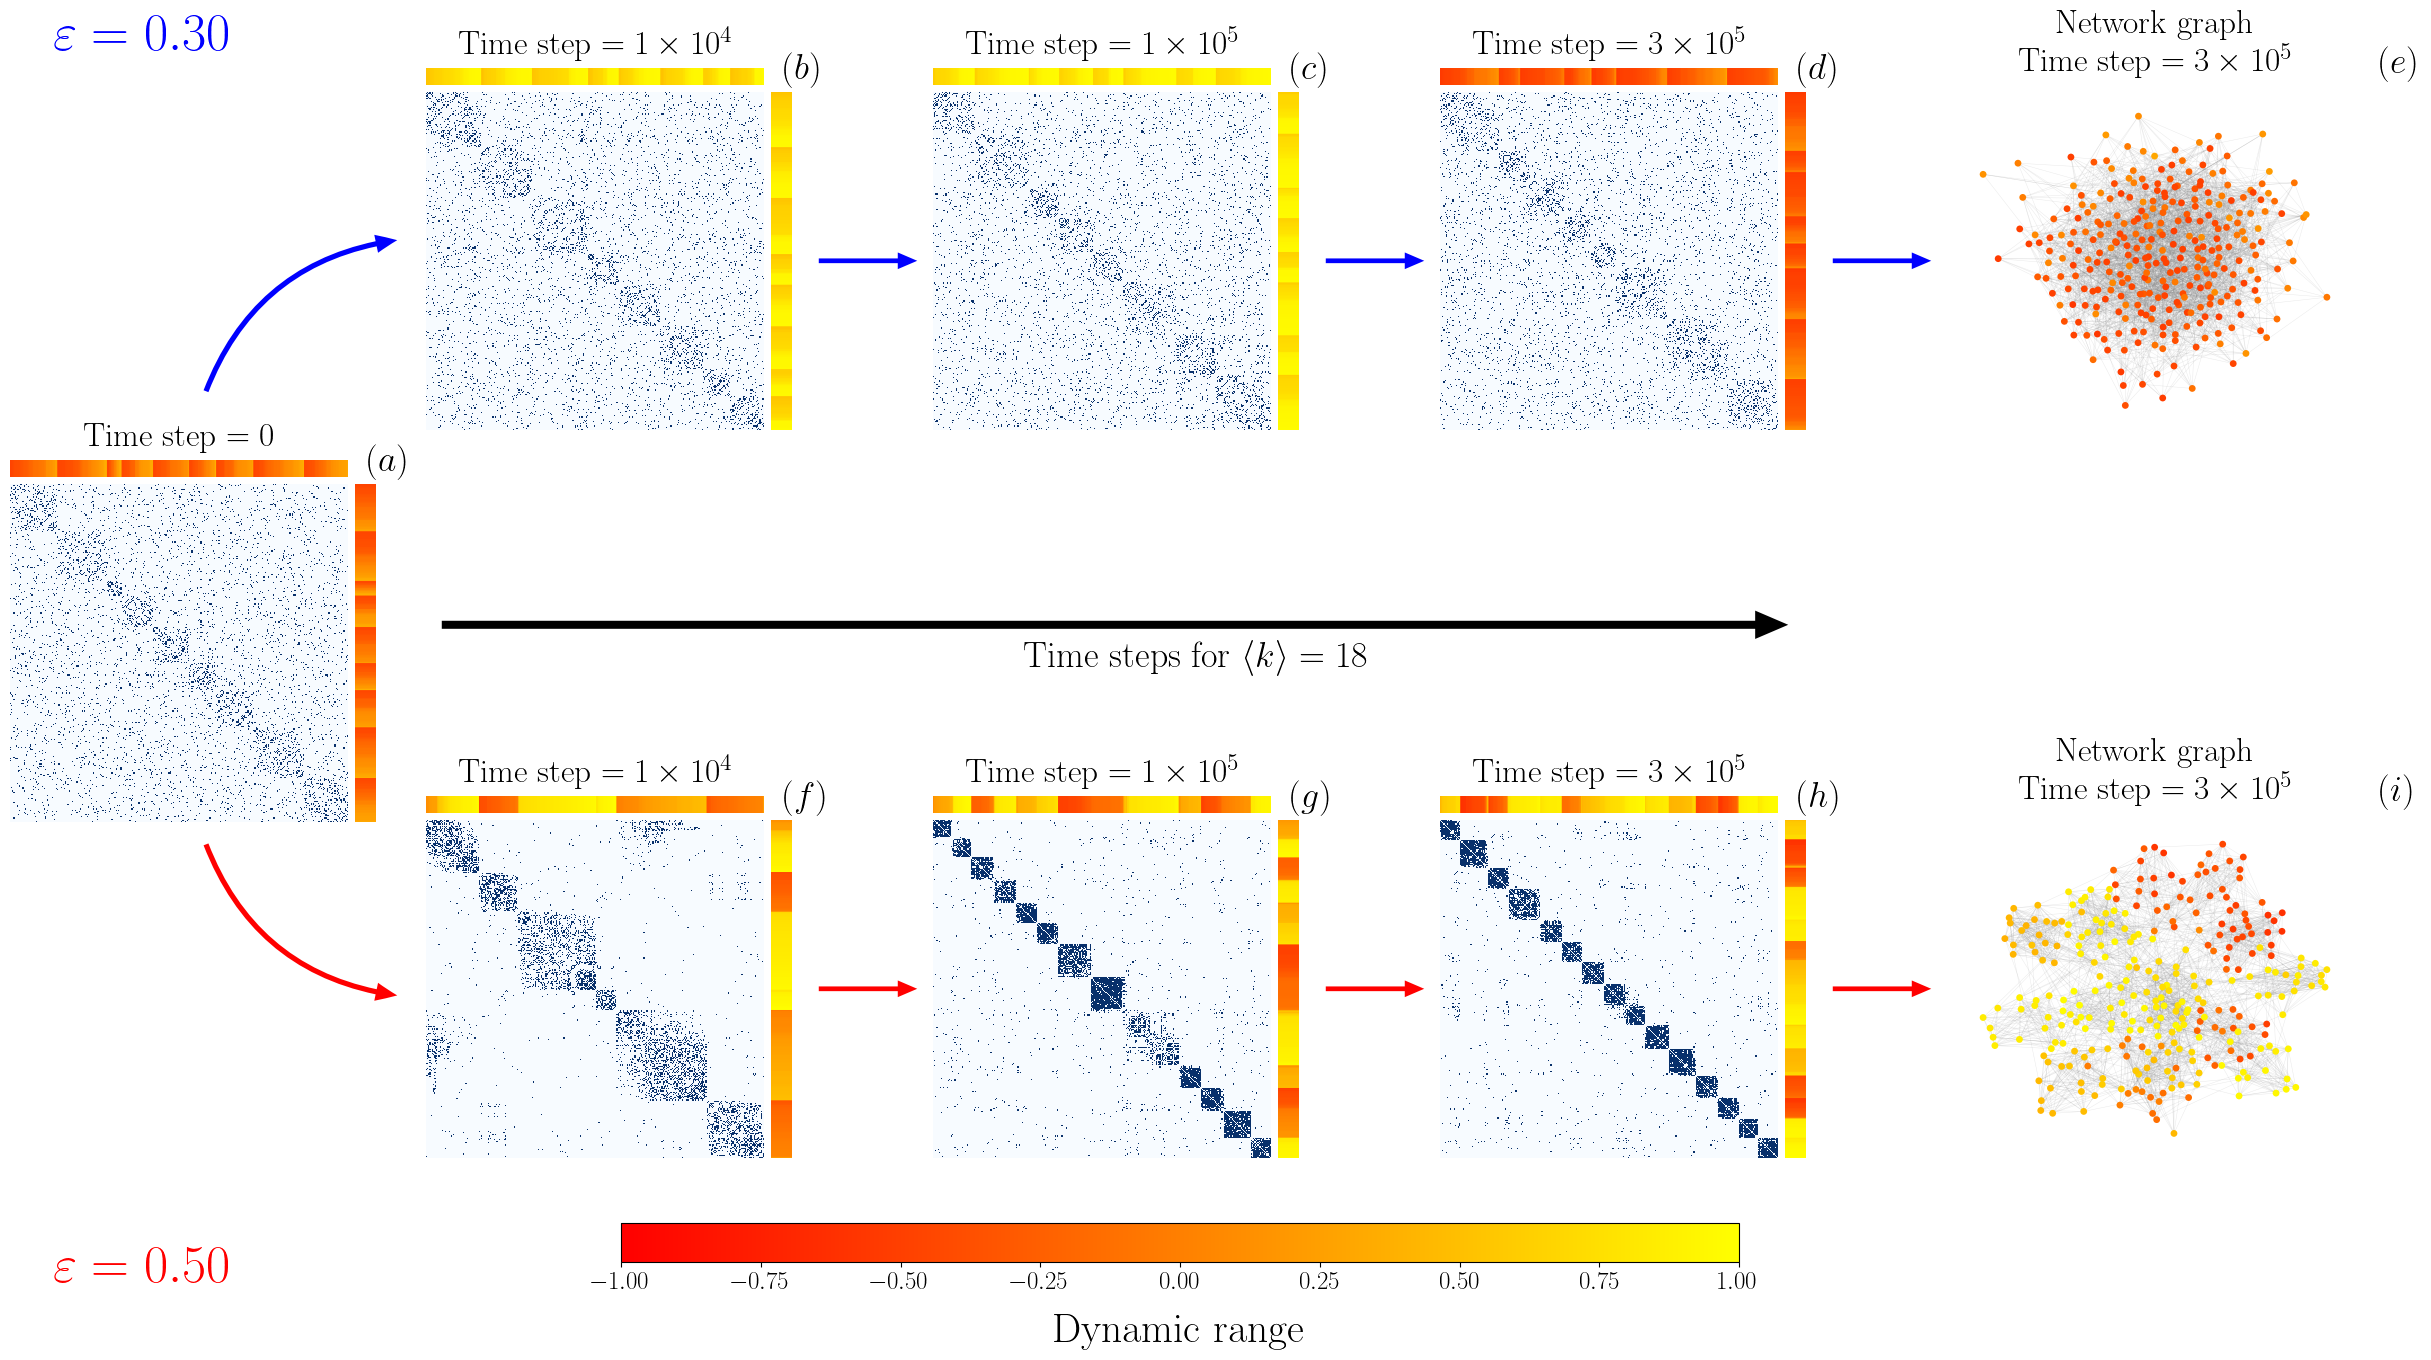

Saved: plots_paper\fig2\figure2_k18_p0.060_sim_1.png
Saved: plots_paper\fig2\figure2_k18_p0.060_sim_1.pdf


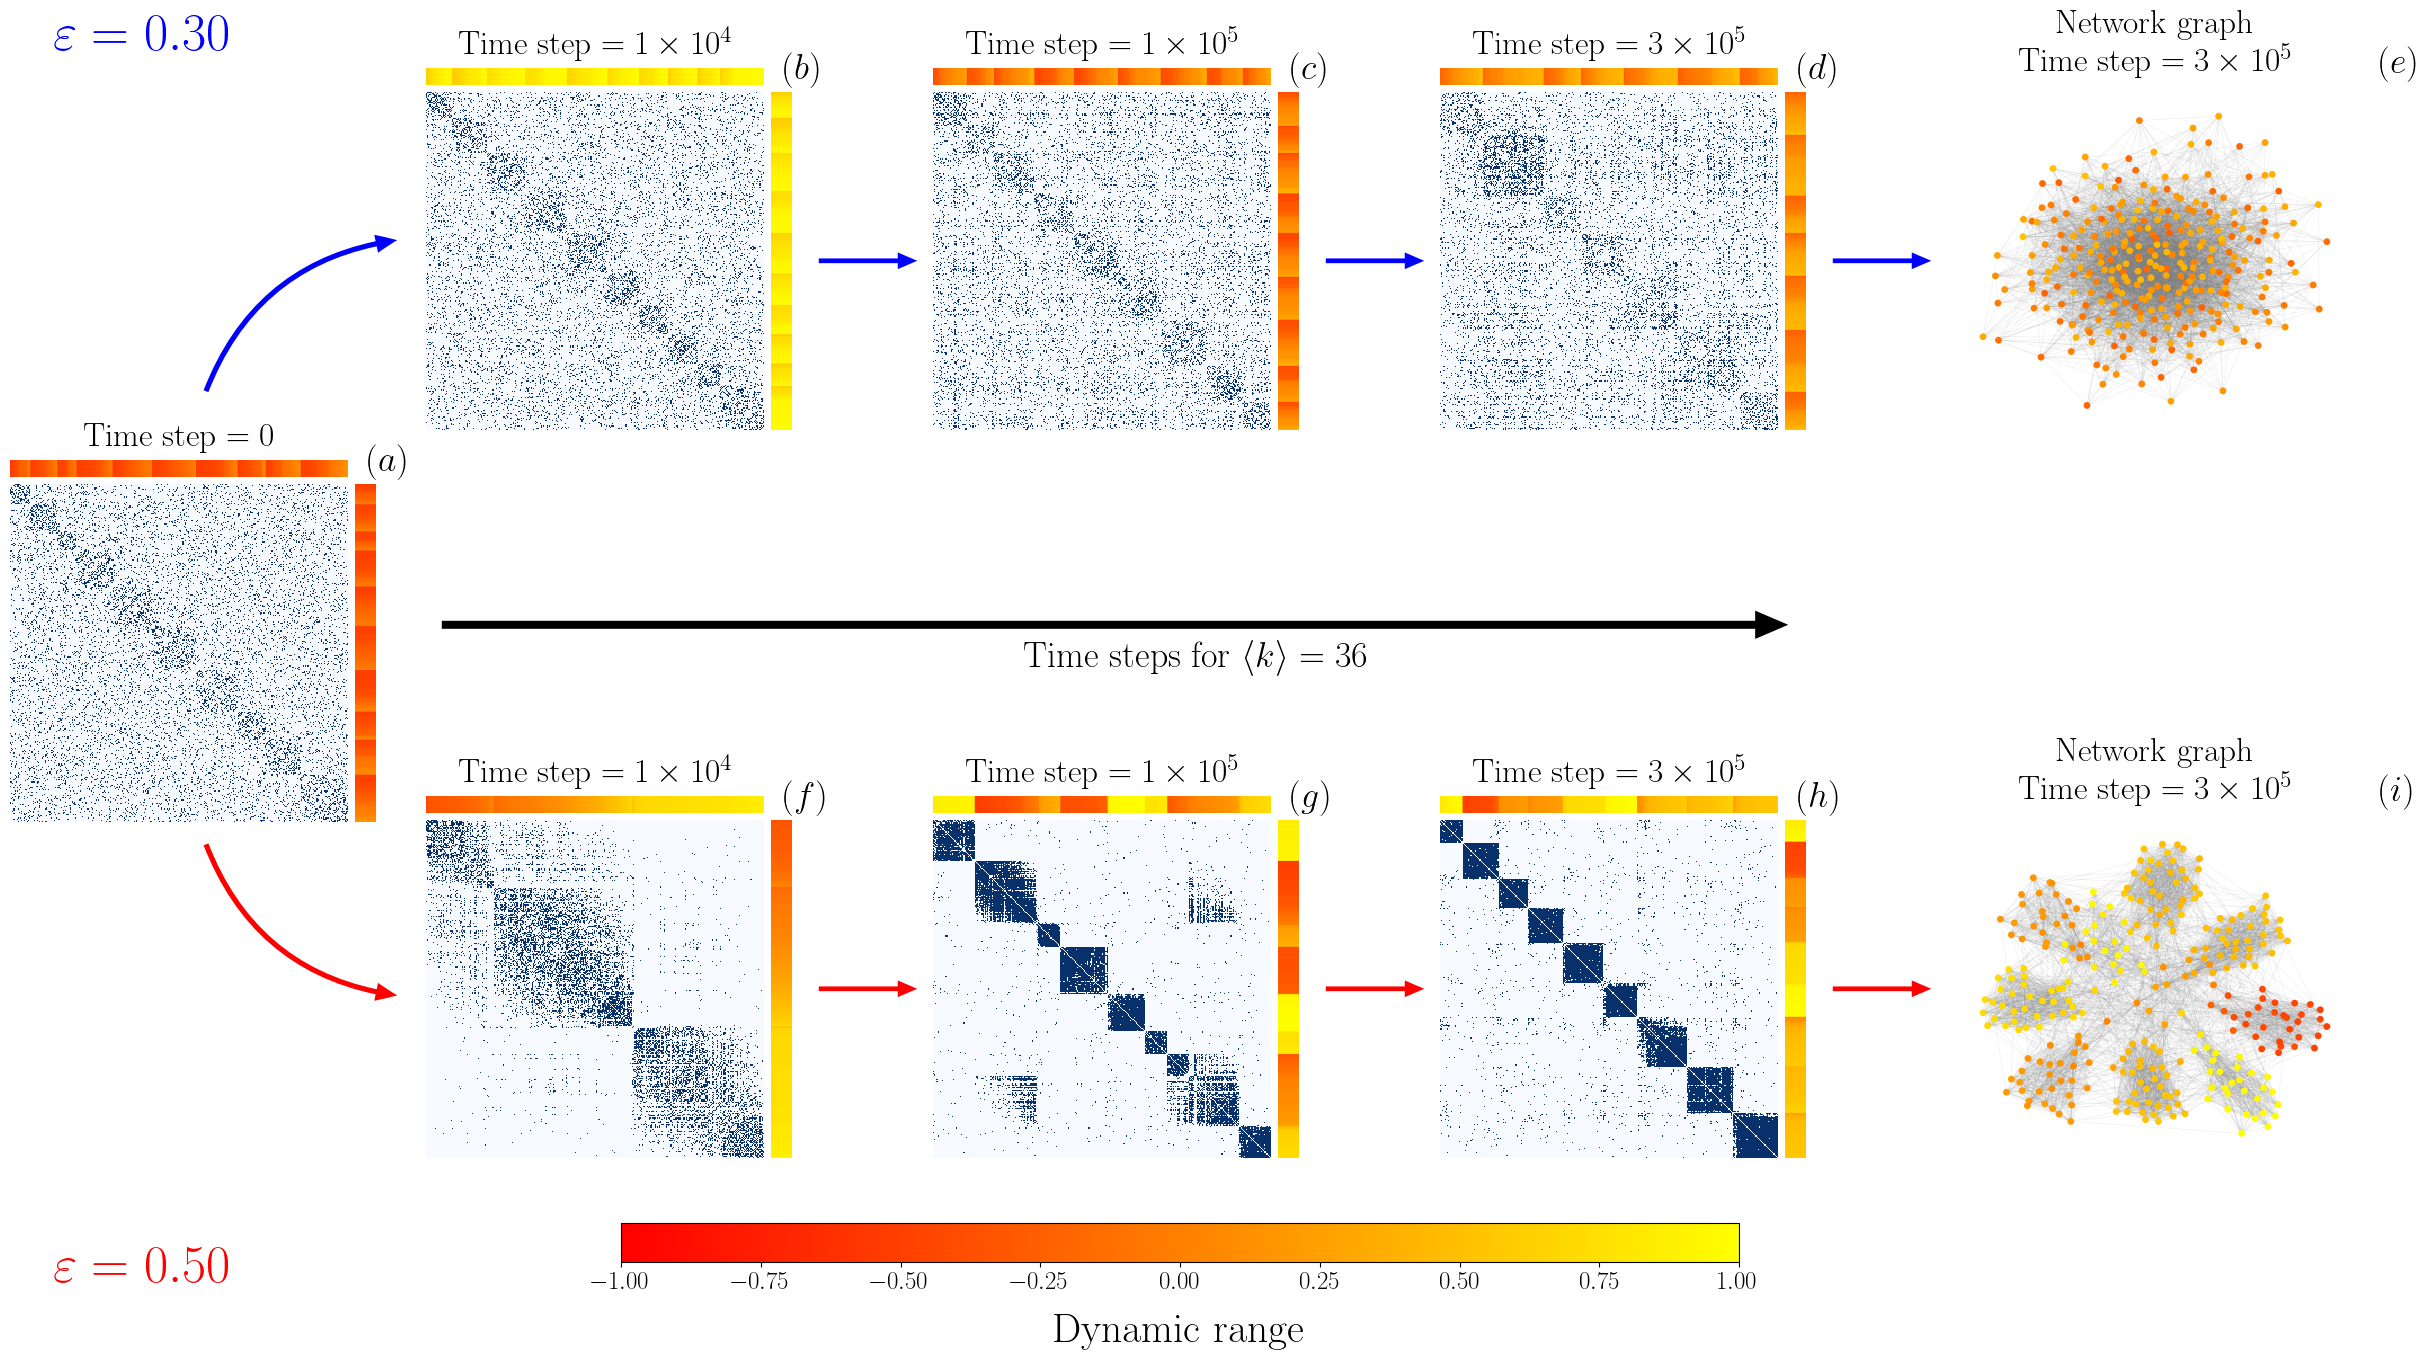

Saved: plots_paper\fig2\figure2_k36_p0.120_sim_1.png
Saved: plots_paper\fig2\figure2_k36_p0.120_sim_1.pdf


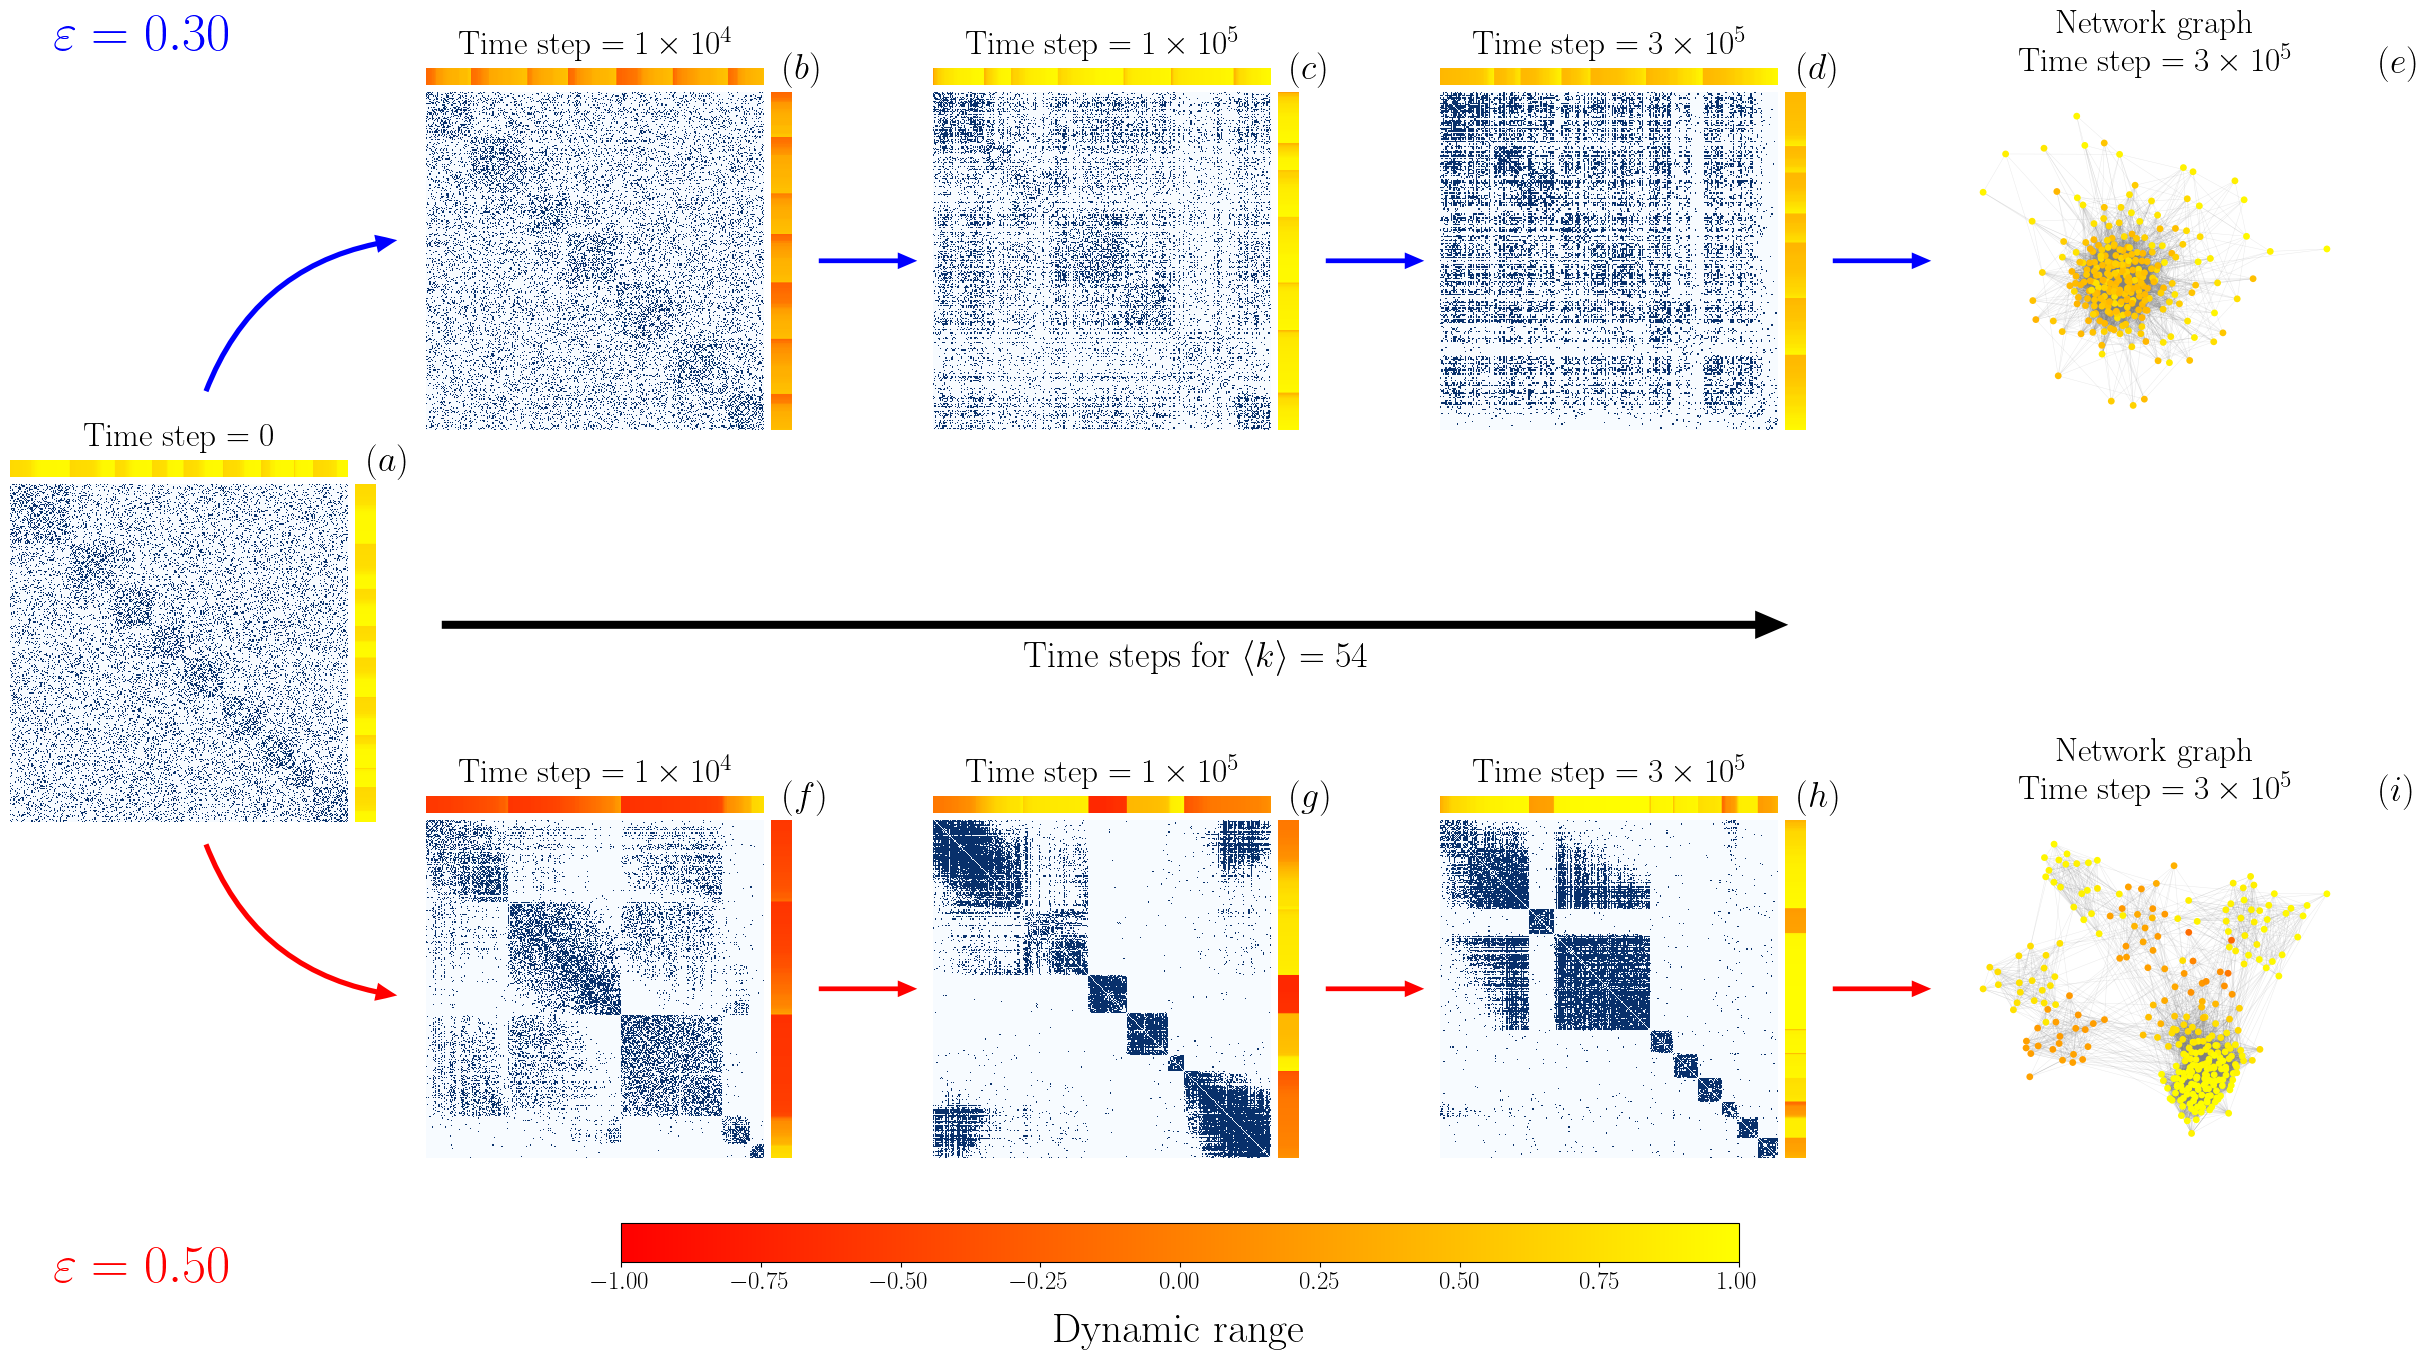

Saved: plots_paper\fig2\figure2_k54_p0.180_sim_1.png
Saved: plots_paper\fig2\figure2_k54_p0.180_sim_1.pdf


In [25]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import community.community_louvain as community_louvain
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

SIMULATION_ID = globals().get("SIMULATION_ID", 1)
FIG2_SIMULATION_ID = globals().get("FIG2_SIMULATION_ID", SIMULATION_ID)
FIG2_K = globals().get("FIG2_K", 18)
FIG2_K_LIST = globals().get("FIG2_K_LIST", [18, 36, 54])
ROOT = Path("results")
out_dir = Path("plots_paper/fig2")
out_dir.mkdir(parents=True, exist_ok=True)

k_to_p = {18: 0.060, 36: 0.120, 54: 0.180}
STATE_CMAP = cm.autumn
STATE_NORM = plt.Normalize(vmin=-1, vmax=1)
LOUVAIN_SEED = 42
LAYOUT_SEED = 42

PANEL_TITLE_FS = 24
PANEL_LABEL_FS = 26
SUPTITLE_FS = 30
EPS_LABEL_FS = 38


def _load_txt(path: Path):
    try:
        return np.loadtxt(path, delimiter=",")
    except Exception:
        return np.loadtxt(path)


def _sci_tex(n: int) -> str:
    if n == 0:
        return "0"
    s = f"{n:.0e}"
    a, b = s.split("e")
    mant = int(float(a))
    exp = int(b)
    return rf"{mant} \times 10^{{{exp}}}"


def _load_ordered_matrix_state(k: int, eps: float, step: int, sim_id: int):
    p_str = f"{k_to_p[k]:.3f}"
    eps_str = f"{eps:.3f}"
    base = ROOT / f"results_p{p_str}" / f"simulation_{sim_id}"
    m_path = base / "networks" / f"eps_{eps_str}" / f"matrix_eps_{eps_str}_step_{step}.txt"
    s_path = base / "states" / f"eps_{eps_str}" / f"states_eps_{eps_str}_step_{step}.txt"

    if (not m_path.exists()) or (not s_path.exists()):
        raise FileNotFoundError(f"Missing files for k={k}, eps={eps_str}, step={step}, sim={sim_id}")

    A = _load_txt(m_path)
    x = np.asarray(_load_txt(s_path)).reshape(-1)

    if A.ndim == 1:
        n = int(np.sqrt(A.size))
        if n * n == A.size:
            A = A.reshape(n, n)

    if x.size != A.shape[0]:
        raise ValueError(f"Size mismatch at step={step}: A has {A.shape[0]}, states has {x.size}")

    G = nx.from_numpy_array(A)
    part = community_louvain.best_partition(G, random_state=LOUVAIN_SEED)
    order = np.array(sorted(part.keys(), key=lambda i: (part[i], x[i])), dtype=int)

    A_ord = A[np.ix_(order, order)]
    x_ord = x[order]
    return A_ord, x_ord, G, x


def _draw_matrix_panel(fig, rect, A_ord, x_ord, title, panel_label):
    ax = fig.add_axes(rect)
    vmax = max(1.0, float(np.nanmax(A_ord)))
    ax.imshow(A_ord, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax, aspect="equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=PANEL_TITLE_FS, pad=10)
    ax.text(1.06, 1.01, rf"$({panel_label})$", transform=ax.transAxes, fontsize=PANEL_LABEL_FS, va="bottom")

    ax_top = ax.inset_axes([0.0, 1.02, 1.0, 0.05], transform=ax.transAxes)
    ax_top.imshow(x_ord.reshape(1, -1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_frame_on(False)
    ax_top.set_clip_on(False)

    ax_right = ax.inset_axes([1.02, 0.0, 0.06, 1.0], transform=ax.transAxes)
    ax_right.imshow(x_ord.reshape(-1, 1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    ax_right.set_frame_on(False)
    ax_right.set_clip_on(False)
    return ax


def _draw_graph_panel(fig, rect, G, x, title, panel_label):
    ax = fig.add_axes(rect)
    pos = nx.spring_layout(G, seed=LAYOUT_SEED)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.17, width=0.35, edge_color="gray")
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=24,
        node_color=x,
        cmap=STATE_CMAP,
        vmin=STATE_NORM.vmin,
        vmax=STATE_NORM.vmax,
        linewidths=0.0,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=PANEL_TITLE_FS, pad=10)
    ax.text(1.04, 1.01, rf"$({panel_label})$", transform=ax.transAxes, fontsize=PANEL_LABEL_FS, va="bottom")
    for spine in ax.spines.values():
        spine.set_visible(False)
    return ax


def _add_arrow(fig, start, end, color, rad=0.0, scale=1.0, z=6):
    arr = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle=f"Simple,head_length={14 * scale},head_width={12 * scale},tail_width={3.4 * scale}",
        color=color,
        linewidth=0,
        zorder=z,
    )
    fig.add_artist(arr)


def plot_figure2_story(k: int = FIG2_K, sim_id: int = FIG2_SIMULATION_ID):
    eps_top = 0.30
    eps_bottom = 0.50
    steps = (0, 10000, 100000, 300000)

    A0, x0, _, _ = _load_ordered_matrix_state(k, eps_top, steps[0], sim_id)

    top_data = [_load_ordered_matrix_state(k, eps_top, s, sim_id) for s in steps[1:]]
    bot_data = [_load_ordered_matrix_state(k, eps_bottom, s, sim_id) for s in steps[1:]]

    _, _, G_top_final, x_top_final = _load_ordered_matrix_state(k, eps_top, steps[-1], sim_id)
    _, _, G_bot_final, x_bot_final = _load_ordered_matrix_state(k, eps_bottom, steps[-1], sim_id)

    fig = plt.figure(figsize=(26, 14), facecolor="white")

    rect_a = [0.055, 0.35, 0.13, 0.25]
    rect_top = [[0.215, 0.63, 0.13, 0.25], [0.41, 0.63, 0.13, 0.25], [0.605, 0.63, 0.13, 0.25]]
    rect_bot = [[0.215, 0.11, 0.13, 0.25], [0.41, 0.11, 0.13, 0.25], [0.605, 0.11, 0.13, 0.25]]
    rect_g_top = [0.80, 0.63, 0.16, 0.25]
    rect_g_bot = [0.80, 0.11, 0.16, 0.25]

    _draw_matrix_panel(
        fig,
        rect_a,
        A0,
        x0,
        r"$\mathrm{Time\ step} = 0$",
        "a",
    )

    top_labels = ["b", "c", "d"]
    for j, (A_ord, x_ord, _, _) in enumerate(top_data):
        step = steps[j + 1]
        _draw_matrix_panel(
            fig,
            rect_top[j],
            A_ord,
            x_ord,
            rf"$\mathrm{{Time\ step}} = {_sci_tex(step)}$",
            top_labels[j],
        )

    bot_labels = ["f", "g", "h"]
    for j, (A_ord, x_ord, _, _) in enumerate(bot_data):
        step = steps[j + 1]
        _draw_matrix_panel(
            fig,
            rect_bot[j],
            A_ord,
            x_ord,
            rf"$\mathrm{{Time\ step}} = {_sci_tex(step)}$",
            bot_labels[j],
        )

    _draw_graph_panel(
        fig,
        rect_g_top,
        G_top_final,
        x_top_final,
        f"$\\mathrm{{Network\ graph}}$\n$\\mathrm{{Time\ step}} = {_sci_tex(steps[-1])}$",
        "e",
    )
    _draw_graph_panel(
        fig,
        rect_g_bot,
        G_bot_final,
        x_bot_final,
        f"$\\mathrm{{Network\ graph}}$\n$\\mathrm{{Time\ step}} = {_sci_tex(steps[-1])}$",
        "i",
    )

    fig.text(0.072, 0.905, rf"$\varepsilon = {eps_top:.2f}$", color="blue", fontsize=EPS_LABEL_FS)
    fig.text(0.072, 0.025, rf"$\varepsilon = {eps_bottom:.2f}$", color="red", fontsize=EPS_LABEL_FS)

    _add_arrow(fig, (0.13, 0.66), (0.205, 0.77), color="blue", rad=-0.30, scale=1.1)
    _add_arrow(fig, (0.13, 0.34), (0.205, 0.23), color="red", rad=0.30, scale=1.1)

    _add_arrow(fig, (0.365, 0.755), (0.405, 0.755), color="blue", scale=1.0)
    _add_arrow(fig, (0.56, 0.755), (0.600, 0.755), color="blue", scale=1.0)
    _add_arrow(fig, (0.755, 0.755), (0.795, 0.755), color="blue", scale=1.0)

    _add_arrow(fig, (0.365, 0.235), (0.405, 0.235), color="red", scale=1.0)
    _add_arrow(fig, (0.56, 0.235), (0.600, 0.235), color="red", scale=1.0)
    _add_arrow(fig, (0.755, 0.235), (0.795, 0.235), color="red", scale=1.0)

    _add_arrow(fig, (0.22, 0.495), (0.74, 0.495), color="black", scale=1.7, z=5)
    fig.text(0.445, 0.465, rf"$\mathrm{{Time\ steps\ for}}\ \langle k \rangle = {k}$", fontsize=26)

    cax = fig.add_axes([0.29, 0.040, 0.43, 0.028])
    sm = cm.ScalarMappable(cmap=STATE_CMAP, norm=STATE_NORM)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(r"$\mathrm{Dynamic\ range}$", fontsize=30, labelpad=14)
    cbar.ax.tick_params(labelsize=18)

    p_str = f"{k_to_p[k]:.3f}"
    out_base = out_dir / f"figure2_k{k}_p{p_str}_sim_{sim_id}"
    png_file = f"{out_base}.png"
    pdf_file = f"{out_base}.pdf"
    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_file, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {png_file}")
    print(f"Saved: {pdf_file}")


for k in FIG2_K_LIST:
    if k not in k_to_p:
        print(f"Skipping unsupported k={k}")
        continue
    plot_figure2_story(k=k, sim_id=FIG2_SIMULATION_ID)


## Figure 3

In [ ]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import community.community_louvain as community_louvain
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

SIMULATION_ID = globals().get("SIMULATION_ID", 1)
FIG3_SIMULATION_ID = globals().get("FIG3_SIMULATION_ID", SIMULATION_ID)
FIG3_K = globals().get("FIG3_K", 36)
FIG3_EPS = globals().get("FIG3_EPS", 0.50)
ROOT = Path("results")
out_dir = Path("plots_paper/fig3")
out_dir.mkdir(parents=True, exist_ok=True)

k_to_p = {18: 0.060, 36: 0.120, 54: 0.180}
STATE_CMAP = cm.autumn
STATE_NORM = plt.Normalize(vmin=-1, vmax=1)
LOUVAIN_SEED = 42
LAYOUT_SEED = 42

PANEL_TITLE_FS = 32
PANEL_LABEL_FS = 26
GRAPH_TITLE_FS = 27


def _load_txt(path: Path):
    try:
        return np.loadtxt(path, delimiter=",")
    except Exception:
        return np.loadtxt(path)


def _sci_tex(n: int) -> str:
    if n == 0:
        return "0"
    s = f"{n:.0e}"
    a, b = s.split("e")
    mant = int(float(a))
    exp = int(b)
    return rf"{mant} \times 10^{{{exp}}}"


def _load_ordered_matrix_state(k: int, eps: float, step: int, sim_id: int):
    p_str = f"{k_to_p[k]:.3f}"
    eps_str = f"{eps:.3f}"
    base = ROOT / f"results_p{p_str}" / f"simulation_{sim_id}"
    m_path = base / "networks" / f"eps_{eps_str}" / f"matrix_eps_{eps_str}_step_{step}.txt"
    s_path = base / "states" / f"eps_{eps_str}" / f"states_eps_{eps_str}_step_{step}.txt"

    if (not m_path.exists()) or (not s_path.exists()):
        raise FileNotFoundError(f"Missing files for k={k}, eps={eps_str}, step={step}, sim={sim_id}")

    A = _load_txt(m_path)
    x = np.asarray(_load_txt(s_path)).reshape(-1)

    if A.ndim == 1:
        n = int(np.sqrt(A.size))
        if n * n == A.size:
            A = A.reshape(n, n)

    if x.size != A.shape[0]:
        raise ValueError(f"Size mismatch at step={step}: A has {A.shape[0]}, states has {x.size}")

    G = nx.from_numpy_array(A)
    part = community_louvain.best_partition(G, random_state=LOUVAIN_SEED)
    order = np.array(sorted(part.keys(), key=lambda i: (part[i], x[i])), dtype=int)

    A_ord = A[np.ix_(order, order)]
    x_ord = x[order]
    return A_ord, x_ord, G, x


def _draw_matrix_panel(fig, rect, A_ord, x_ord, title, panel_label):
    ax = fig.add_axes(rect)
    vmax = max(1.0, float(np.nanmax(A_ord)))
    ax.imshow(A_ord, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax, aspect="equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=PANEL_TITLE_FS, pad=8)
    ax.text(1.12, 1.01, rf"$({panel_label})$", transform=ax.transAxes, fontsize=PANEL_LABEL_FS, va="bottom")

    ax_top = ax.inset_axes([0.0, 1.02, 1.0, 0.045], transform=ax.transAxes)
    ax_top.imshow(x_ord.reshape(1, -1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_frame_on(False)
    ax_top.set_clip_on(False)

    ax_right = ax.inset_axes([1.02, 0.0, 0.06, 1.0], transform=ax.transAxes)
    ax_right.imshow(x_ord.reshape(-1, 1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    ax_right.set_frame_on(False)
    ax_right.set_clip_on(False)
    return ax


def _draw_graph_panel(fig, rect, G, x, title, panel_label):
    ax = fig.add_axes(rect)
    pos = nx.spring_layout(G, seed=LAYOUT_SEED)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.17, width=0.35, edge_color="gray")
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=52,
        node_color=x,
        cmap=STATE_CMAP,
        vmin=STATE_NORM.vmin,
        vmax=STATE_NORM.vmax,
        linewidths=0.0,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=GRAPH_TITLE_FS, pad=8)
    ax.text(1.03, 1.01, rf"$({panel_label})$", transform=ax.transAxes, fontsize=PANEL_LABEL_FS, va="bottom")
    for spine in ax.spines.values():
        spine.set_visible(False)
    return ax


def _add_arrow(fig, start, end, color, rad=0.0, scale=1.0, z=6):
    arr = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle=f"Simple,head_length={14 * scale},head_width={12 * scale},tail_width={3.4 * scale}",
        color=color,
        linewidth=0,
        zorder=z,
    )
    fig.add_artist(arr)


def plot_figure3_linear(k: int = FIG3_K, eps: float = FIG3_EPS, sim_id: int = FIG3_SIMULATION_ID):
    if k not in k_to_p:
        raise ValueError(f"Unsupported k={k}. Expected one of {sorted(k_to_p)}")

    steps = (0, 10000, 100000, 300000)
    step_titles = [
        r"$\mathrm{Time\ step} = 0$",
        rf"$\mathrm{{Time\ step}} = {_sci_tex(10000)}$",
        rf"$\mathrm{{Time\ step}} = {_sci_tex(100000)}$",
        rf"$\mathrm{{Time\ step}} = {_sci_tex(300000)}$",
    ]

    data = [_load_ordered_matrix_state(k, eps, s, sim_id) for s in steps]
    _, _, G_final, x_final = data[-1]

    fig = plt.figure(figsize=(29, 9), facecolor="white")

    rect_mats = [
        [0.03, 0.22, 0.12, 0.56],
        [0.21, 0.22, 0.12, 0.56],
        [0.39, 0.22, 0.12, 0.56],
        [0.57, 0.22, 0.12, 0.56],
    ]
    rect_graph = [0.74, 0.22, 0.21, 0.56]

    labels = ["a", "b", "c", "d"]
    for i, (A_ord, x_ord, _, _) in enumerate(data):
        _draw_matrix_panel(fig, rect_mats[i], A_ord, x_ord, step_titles[i], labels[i])

    _draw_graph_panel(
        fig,
        rect_graph,
        G_final,
        x_final,
        f"$\\mathrm{{Network\ graph}}$\n$\\mathrm{{Time\ step}} = {_sci_tex(steps[-1])}$",
        "e",
    )

    # Top time arrow and caption
    _add_arrow(fig, (0.14, 0.92), (0.73, 0.92), color="black", scale=2.0, z=5)
    fig.text(0.33, 0.845, rf"$\mathrm{{Time\ Steps\ for}}\ \langle k \rangle = {k}$", fontsize=40)

    # Red transition arrows between panels
    y_arrow = 0.51
    _add_arrow(fig, (0.168, y_arrow), (0.198, y_arrow), color="red", scale=1.1)
    _add_arrow(fig, (0.348, y_arrow), (0.378, y_arrow), color="red", scale=1.1)
    _add_arrow(fig, (0.528, y_arrow), (0.558, y_arrow), color="red", scale=1.1)
    _add_arrow(fig, (0.708, y_arrow), (0.738, y_arrow), color="red", scale=1.1)

    # Dynamic range colorbar
    cax = fig.add_axes([0.24, 0.10, 0.42, 0.035])
    sm = cm.ScalarMappable(cmap=STATE_CMAP, norm=STATE_NORM)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(r"$\mathrm{Dynamic\ range}$", fontsize=38, labelpad=20)
    cbar.ax.tick_params(labelsize=22)
    fig.text(0.08, 0.115, rf"$\varepsilon = {eps:.2f}$", color="red", fontsize=34)

    p_str = f"{k_to_p[k]:.3f}"
    eps_tag = f"{eps:.3f}".rstrip("0").rstrip(".").replace(".", "_")
    out_base = out_dir / f"figure3_k{k}_p{p_str}_eps_{eps_tag}_sim_{sim_id}"
    png_file = f"{out_base}.png"
    pdf_file = f"{out_base}.pdf"
    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_file, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {png_file}")
    print(f"Saved: {pdf_file}")


plot_figure3_linear(k=FIG3_K, eps=FIG3_EPS, sim_id=FIG3_SIMULATION_ID)


## Figure 4

In [ ]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import community.community_louvain as community_louvain
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

SIMULATION_ID = globals().get("SIMULATION_ID", 1)
FIG4_SIMULATION_ID = globals().get("FIG4_SIMULATION_ID", SIMULATION_ID)
FIG4_K = globals().get("FIG4_K", 54)
FIG4_EPS = globals().get("FIG4_EPS", 0.50)
ROOT = Path("results")
out_dir = Path("plots_paper/fig4")
out_dir.mkdir(parents=True, exist_ok=True)

k_to_p = {18: 0.060, 36: 0.120, 54: 0.180}
STATE_CMAP = cm.autumn
STATE_NORM = plt.Normalize(vmin=-1, vmax=1)
LOUVAIN_SEED = 42
LAYOUT_SEED = 42

PANEL_TITLE_FS = 32
PANEL_LABEL_FS = 26
GRAPH_TITLE_FS = 27


def _load_txt(path: Path):
    try:
        return np.loadtxt(path, delimiter=",")
    except Exception:
        return np.loadtxt(path)


def _sci_tex(n: int) -> str:
    if n == 0:
        return "0"
    s = f"{n:.0e}"
    a, b = s.split("e")
    mant = int(float(a))
    exp = int(b)
    return rf"{mant} \times 10^{{{exp}}}"


def _load_ordered_matrix_state(k: int, eps: float, step: int, sim_id: int):
    p_str = f"{k_to_p[k]:.3f}"
    eps_str = f"{eps:.3f}"
    base = ROOT / f"results_p{p_str}" / f"simulation_{sim_id}"
    m_path = base / "networks" / f"eps_{eps_str}" / f"matrix_eps_{eps_str}_step_{step}.txt"
    s_path = base / "states" / f"eps_{eps_str}" / f"states_eps_{eps_str}_step_{step}.txt"

    if (not m_path.exists()) or (not s_path.exists()):
        raise FileNotFoundError(f"Missing files for k={k}, eps={eps_str}, step={step}, sim={sim_id}")

    A = _load_txt(m_path)
    x = np.asarray(_load_txt(s_path)).reshape(-1)

    if A.ndim == 1:
        n = int(np.sqrt(A.size))
        if n * n == A.size:
            A = A.reshape(n, n)

    if x.size != A.shape[0]:
        raise ValueError(f"Size mismatch at step={step}: A has {A.shape[0]}, states has {x.size}")

    G = nx.from_numpy_array(A)
    part = community_louvain.best_partition(G, random_state=LOUVAIN_SEED)
    order = np.array(sorted(part.keys(), key=lambda i: (part[i], x[i])), dtype=int)

    A_ord = A[np.ix_(order, order)]
    x_ord = x[order]
    return A_ord, x_ord, G, x


def _draw_matrix_panel(fig, rect, A_ord, x_ord, title, panel_label):
    ax = fig.add_axes(rect)
    vmax = max(1.0, float(np.nanmax(A_ord)))
    ax.imshow(A_ord, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax, aspect="equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=PANEL_TITLE_FS, pad=8)
    ax.text(1.12, 1.01, rf"$({panel_label})$", transform=ax.transAxes, fontsize=PANEL_LABEL_FS, va="bottom")

    ax_top = ax.inset_axes([0.0, 1.02, 1.0, 0.045], transform=ax.transAxes)
    ax_top.imshow(x_ord.reshape(1, -1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_frame_on(False)
    ax_top.set_clip_on(False)

    ax_right = ax.inset_axes([1.02, 0.0, 0.06, 1.0], transform=ax.transAxes)
    ax_right.imshow(x_ord.reshape(-1, 1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    ax_right.set_frame_on(False)
    ax_right.set_clip_on(False)
    return ax


def _draw_graph_panel(fig, rect, G, x, title, panel_label):
    ax = fig.add_axes(rect)
    pos = nx.spring_layout(G, seed=LAYOUT_SEED)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.17, width=0.35, edge_color="gray")
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=52,
        node_color=x,
        cmap=STATE_CMAP,
        vmin=STATE_NORM.vmin,
        vmax=STATE_NORM.vmax,
        linewidths=0.0,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=GRAPH_TITLE_FS, pad=8)
    ax.text(1.03, 1.01, rf"$({panel_label})$", transform=ax.transAxes, fontsize=PANEL_LABEL_FS, va="bottom")
    for spine in ax.spines.values():
        spine.set_visible(False)
    return ax


def _add_arrow(fig, start, end, color, rad=0.0, scale=1.0, z=6):
    arr = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle=f"Simple,head_length={14 * scale},head_width={12 * scale},tail_width={3.4 * scale}",
        color=color,
        linewidth=0,
        zorder=z,
    )
    fig.add_artist(arr)


def plot_figure4_linear(k: int = FIG4_K, eps: float = FIG4_EPS, sim_id: int = FIG4_SIMULATION_ID):
    if k not in k_to_p:
        raise ValueError(f"Unsupported k={k}. Expected one of {sorted(k_to_p)}")

    steps = (0, 10000, 100000, 300000)
    step_titles = [
        r"$\mathrm{Time\ step} = 0$",
        rf"$\mathrm{{Time\ step}} = {_sci_tex(10000)}$",
        rf"$\mathrm{{Time\ step}} = {_sci_tex(100000)}$",
        rf"$\mathrm{{Time\ step}} = {_sci_tex(300000)}$",
    ]

    data = [_load_ordered_matrix_state(k, eps, s, sim_id) for s in steps]
    _, _, G_final, x_final = data[-1]

    fig = plt.figure(figsize=(29, 9), facecolor="white")

    rect_mats = [
        [0.03, 0.22, 0.12, 0.56],
        [0.21, 0.22, 0.12, 0.56],
        [0.39, 0.22, 0.12, 0.56],
        [0.57, 0.22, 0.12, 0.56],
    ]
    rect_graph = [0.74, 0.22, 0.21, 0.56]

    labels = ["a", "b", "c", "d"]
    for i, (A_ord, x_ord, _, _) in enumerate(data):
        _draw_matrix_panel(fig, rect_mats[i], A_ord, x_ord, step_titles[i], labels[i])

    _draw_graph_panel(
        fig,
        rect_graph,
        G_final,
        x_final,
        f"$\\mathrm{{Network\ graph}}$\n$\\mathrm{{Time\ step}} = {_sci_tex(steps[-1])}$",
        "e",
    )

    # Top time arrow and caption
    _add_arrow(fig, (0.14, 0.92), (0.73, 0.92), color="black", scale=2.0, z=5)
    fig.text(0.33, 0.845, rf"$\mathrm{{Time\ Steps\ for}}\ \langle k \rangle = {k}$", fontsize=40)

    # Red transition arrows between panels
    y_arrow = 0.51
    _add_arrow(fig, (0.168, y_arrow), (0.198, y_arrow), color="red", scale=1.1)
    _add_arrow(fig, (0.348, y_arrow), (0.378, y_arrow), color="red", scale=1.1)
    _add_arrow(fig, (0.528, y_arrow), (0.558, y_arrow), color="red", scale=1.1)
    _add_arrow(fig, (0.708, y_arrow), (0.738, y_arrow), color="red", scale=1.1)

    # Dynamic range colorbar
    cax = fig.add_axes([0.24, 0.10, 0.42, 0.035])
    sm = cm.ScalarMappable(cmap=STATE_CMAP, norm=STATE_NORM)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(r"$\mathrm{Dynamic\ range}$", fontsize=38, labelpad=20)
    cbar.ax.tick_params(labelsize=22)
    fig.text(0.08, 0.115, rf"$\varepsilon = {eps:.2f}$", color="red", fontsize=34)

    p_str = f"{k_to_p[k]:.3f}"
    eps_tag = f"{eps:.3f}".rstrip("0").rstrip(".").replace(".", "_")
    out_base = out_dir / f"figure4_k{k}_p{p_str}_eps_{eps_tag}_sim_{sim_id}"
    png_file = f"{out_base}.png"
    pdf_file = f"{out_base}.pdf"
    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_file, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {png_file}")
    print(f"Saved: {pdf_file}")


plot_figure4_linear(k=FIG4_K, eps=FIG4_EPS, sim_id=FIG4_SIMULATION_ID)


# **Figure 5**. Degree Distribution.

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# === Plot style settings ===
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

SIMULATION_ID = globals().get("SIMULATION_ID", 1)
SIMULATION_IDS = globals().get("SIMULATION_IDS", [SIMULATION_ID])

# === General configuration ===
k_to_p = {18: 0.060, 36: 0.120, 54: 0.180}
epsilons = [0.3, 0.5]
steps = [0, 10_000, 100_000, 300_000]
step_titles = [
    r"Time step $0$",
    r"Time step $1 \times 10^{4}$",
    r"Time step $1 \times 10^{5}$",
    r"Time step $3 \times 10^{5}$"
]

# === Customizable parameters ===
N = 300  # total number of nodes (constant)
max_grado = N - 1
ylim_y = 0.12  # Expected maximum height for P(k)
xlim_x = 180
mostrar_dispersion = False  # Set to True to show ±std shaded areas

# === Visual style ===
BIN_WIDTH = 2  # 1 = raw integer bins, 2 = smoother grouped bins
bin_edges = np.arange(0, max_grado + BIN_WIDTH + 1, BIN_WIDTH)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = np.diff(bin_edges)
color_map = {0.3: 'blue', 0.5: 'red'}
label_map = {0.3: r"$\varepsilon = 0.3$", 0.5: r"$\varepsilon = 0.5$"}
alfa_mean = 0.6
alfa_std = 0.25

# === File path templates ===
base_template = "results/results_p{:.3f}/simulation_{}/networks/eps_{:.3f}/matrix_eps_{:.3f}_step_{}.txt"
output_dir = "plots_paper/fig5"
os.makedirs(output_dir, exist_ok=True)

# === Loop over different k values ===
for k, p in k_to_p.items():
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    for idx, (step, title) in enumerate(zip(steps, step_titles)):
        ax = axs[idx]

        for eps in epsilons:
            all_probs = []

            for sim_id in SIMULATION_IDS:
                path = base_template.format(p, sim_id, eps, eps, step)
                if not os.path.exists(path):
                    print(f"Not found: {path}")
                    continue

                try:
                    adj = pd.read_csv(path, header=None).values
                    adj = (adj > 0).astype(int)
                    degrees = adj.sum(axis=1)

                    counts, _ = np.histogram(degrees, bins=bin_edges)
                    # Density-like normalization to keep P(k) scale comparable when BIN_WIDTH changes
                    probs = counts / (N * bin_widths)
                    all_probs.append(probs)

                except Exception as e:
                    print(f"Error reading {path}: {e}")
                    continue

            if all_probs:
                probs_array = np.array(all_probs)
                mean_probs = probs_array.mean(axis=0)
                std_probs = probs_array.std(axis=0)

                ax.bar(bin_centers, mean_probs, width=bin_widths * 0.95, alpha=alfa_mean,
                       color=color_map[eps], label=label_map[eps],
                       edgecolor='black', linewidth=0.5)

                if mostrar_dispersion:
                    ax.fill_between(bin_centers,
                                    mean_probs - std_probs,
                                    mean_probs + std_probs,
                                    color=color_map[eps], alpha=alfa_std)

        # === Subplot aesthetics ===
        ax.set_title(title, fontsize=18)
        ax.set_xlabel("Node Degree $k$", fontsize=18)
        ax.set_ylabel(r"$P(k)$", fontsize=18)  # <- Updated label
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(True)
        ax.set_axisbelow(True)
        if ylim_y is not None:
            ax.set_ylim(0, ylim_y)
        if xlim_x is not None:
            ax.set_xlim(0, xlim_x)

        # Disable scientific notation on axes
        ax.ticklabel_format(style='plain', axis='y')
        ax.ticklabel_format(style='plain', axis='x')

    # === Global legend ===
    handles = [plt.Line2D([0], [0], color=color_map[eps], lw=5, label=label_map[eps]) for eps in epsilons]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
               ncol=len(epsilons), fontsize=16, frameon=False)

    # === Save figure ===
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    output_path = os.path.join(output_dir, f"degree_prob_k{k}")
    plt.savefig(output_path + ".png", dpi=300, bbox_inches='tight')
    plt.savefig(output_path + ".pdf", dpi=300, bbox_inches='tight')
    plt.close()

    print(f"Saved: {output_path}.pdf/png")



✅ Saved: plots_paper/fig5\degree_prob_k18.pdf/png
✅ Saved: plots_paper/fig5\degree_prob_k36.pdf/png
✅ Saved: plots_paper/fig5\degree_prob_k54.pdf/png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# === Plot style settings ===
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

SIMULATION_ID = globals().get("SIMULATION_ID", 1)
SIMULATION_IDS = globals().get("SIMULATION_IDS", [SIMULATION_ID])

# === General configuration ===
k_to_p = {54: 0.180}
epsilons = [0.3, 0.5]
steps = [0, 10_000, 100_000, 300_000]
step_titles = [
    r"Time step $0$",
    r"Time step $1 \times 10^{4}$",
    r"Time step $1 \times 10^{5}$",
    r"Time step $3 \times 10^{5}$"
]

# === Customizable parameters ===
N = 300  # total number of nodes (constant)
max_grado = N - 1
ylim_y = 0.08  # Expected maximum height for P(k)
xlim_x = 180
mostrar_dispersion = False  # Set to True to show ±std shaded areas

# === Visual style ===
BIN_WIDTH = 4  # one bin for each integer degree (k=0,1,2,...)
bin_edges = np.arange(0, max_grado + BIN_WIDTH + 1, BIN_WIDTH)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = np.diff(bin_edges)
color_map = {0.3: 'blue', 0.5: 'red'}
label_map = {0.3: r"$\varepsilon = 0.3$", 0.5: r"$\varepsilon = 0.5$"}
alfa_mean = 0.6
alfa_std = 0.25

# === File path templates ===
base_template = "results/results_p{:.3f}/simulation_{}/networks/eps_{:.3f}/matrix_eps_{:.3f}_step_{}.txt"
output_dir = "plots_paper/fig5"
os.makedirs(output_dir, exist_ok=True)

# === Loop over different k values ===
for k, p in k_to_p.items():
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    for idx, (step, title) in enumerate(zip(steps, step_titles)):
        ax = axs[idx]

        for eps in epsilons:
            all_probs = []

            for sim_id in SIMULATION_IDS:
                path = base_template.format(p, sim_id, eps, eps, step)
                if not os.path.exists(path):
                    print(f"Not found: {path}")
                    continue

                try:
                    adj = pd.read_csv(path, header=None).values
                    adj = (adj > 0).astype(int)
                    degrees = adj.sum(axis=1)

                    counts, _ = np.histogram(degrees, bins=bin_edges)
                    # Density-like normalization to keep P(k) scale comparable when BIN_WIDTH changes
                    probs = counts / (N * bin_widths)
                    all_probs.append(probs)

                except Exception as e:
                    print(f"Error reading {path}: {e}")
                    continue

            if all_probs:
                probs_array = np.array(all_probs)
                mean_probs = probs_array.mean(axis=0)
                std_probs = probs_array.std(axis=0)

                ax.bar(bin_centers, mean_probs, width=bin_widths * 0.95, alpha=alfa_mean,
                       color=color_map[eps], label=label_map[eps],
                       edgecolor='black', linewidth=0.5)

                if mostrar_dispersion:
                    ax.fill_between(bin_centers,
                                    mean_probs - std_probs,
                                    mean_probs + std_probs,
                                    color=color_map[eps], alpha=alfa_std)

        # === Subplot aesthetics ===
        ax.set_title(title, fontsize=18)
        ax.set_xlabel("Node Degree $k$", fontsize=18)
        ax.set_ylabel(r"$P(k)$", fontsize=18)  # <- Updated label
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(True)
        ax.set_axisbelow(True)
        if ylim_y is not None:
            ax.set_ylim(0, ylim_y)
        if xlim_x is not None:
            ax.set_xlim(0, xlim_x)

        # Disable scientific notation on axes
        ax.ticklabel_format(style='plain', axis='y')
        ax.ticklabel_format(style='plain', axis='x')

    # === Global legend ===
    handles = [plt.Line2D([0], [0], color=color_map[eps], lw=5, label=label_map[eps]) for eps in epsilons]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
               ncol=len(epsilons), fontsize=16, frameon=False)

    # === Save figure ===
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    output_path = os.path.join(output_dir, f"fig5")
    plt.savefig(output_path + ".png", dpi=300, bbox_inches='tight')
    plt.savefig(output_path + ".pdf", dpi=300, bbox_inches='tight')
    plt.close()

    print(f"Saved: {output_path}.pdf/png")



Saved: plots_paper/fig5\fig5.pdf/png


# **Abstract Image**

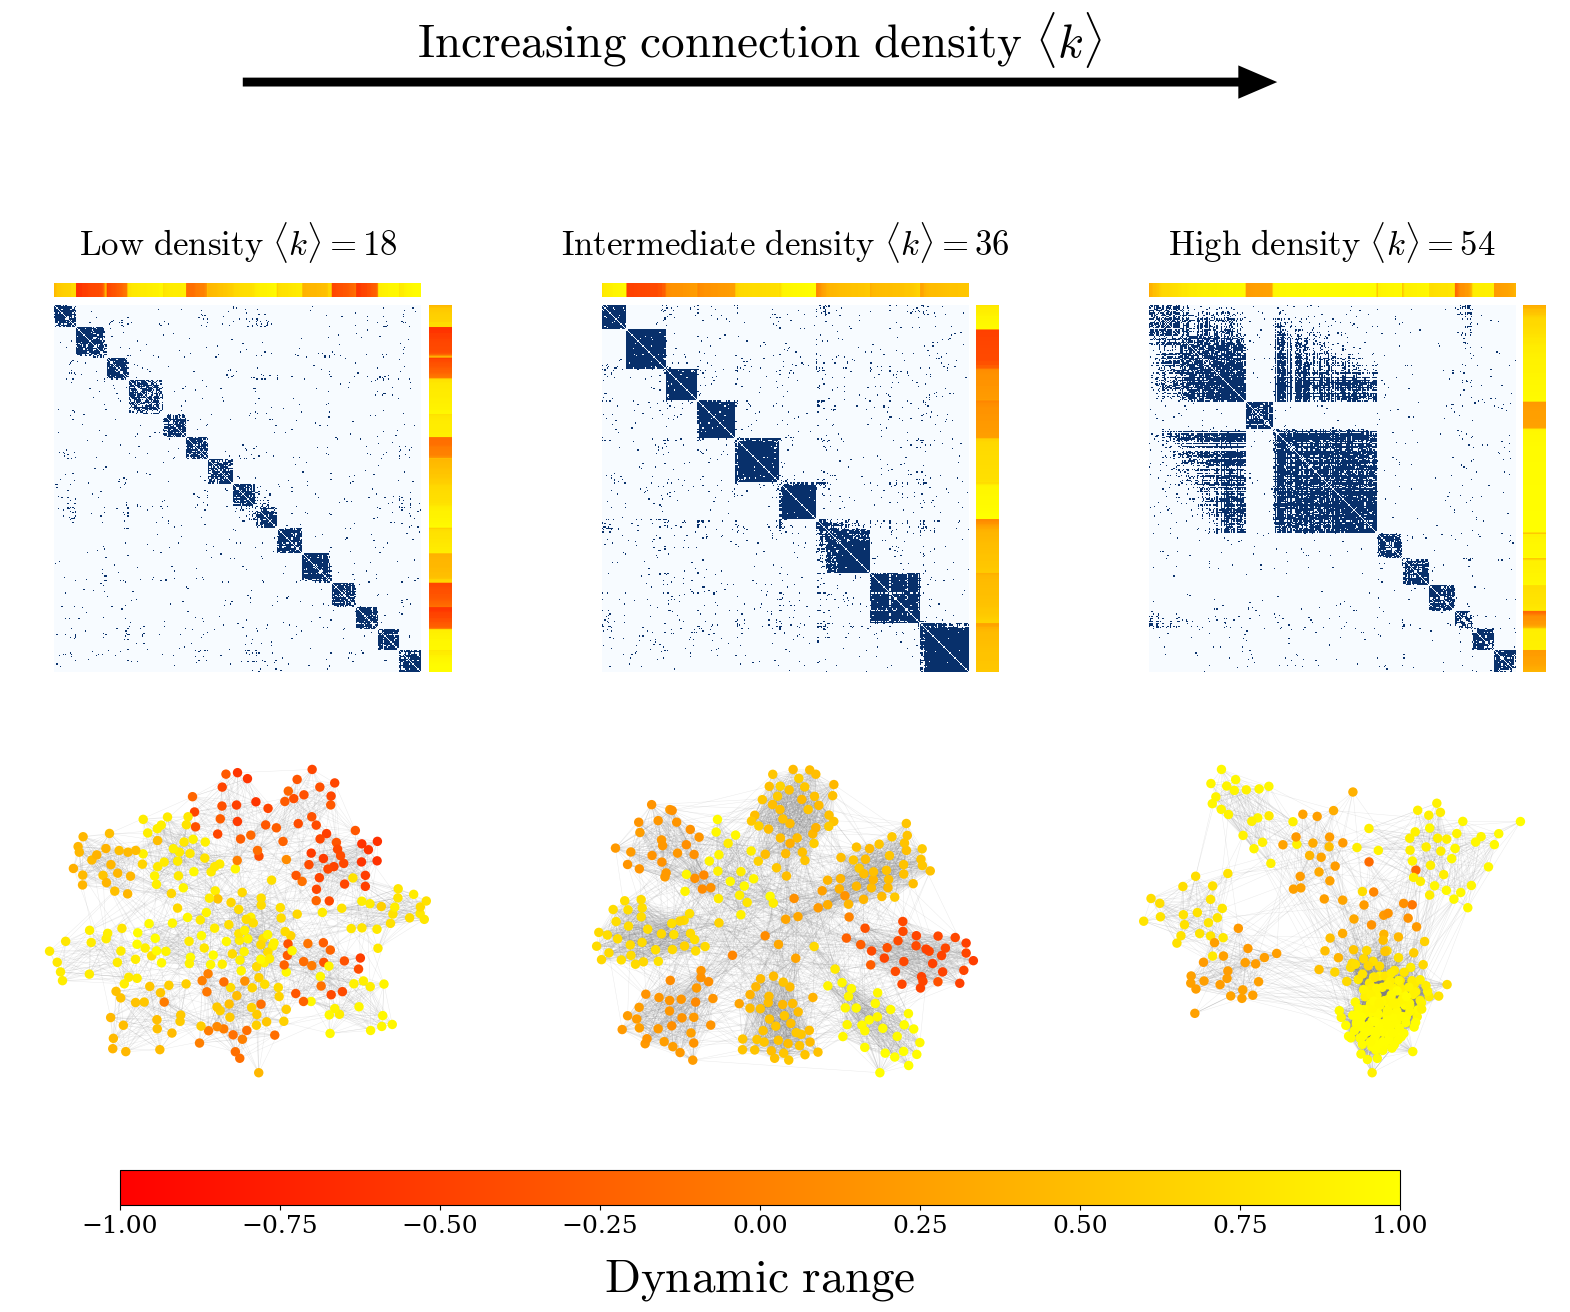

Saved: plots_paper\abstract_image\abstract_image_k18-36-54_eps_0_5_step_300000_sim_1.png
Saved: plots_paper\abstract_image\abstract_image_k18-36-54_eps_0_5_step_300000_sim_1.pdf
Saved: plots_paper\abstract_image\abstract_image_k18-36-54_eps_0_5_step_300000_sim_1.svg


In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import community.community_louvain as community_louvain
from matplotlib.patches import FancyArrowPatch

# --- Style ---
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

# --- Config ---
SIMULATION_ID = globals().get("SIMULATION_ID", 1)
ABSTRACT_SIMULATION_ID = globals().get("ABSTRACT_SIMULATION_ID", SIMULATION_ID)
ABSTRACT_STEP = globals().get("ABSTRACT_STEP", 300000)
ABSTRACT_EPS = globals().get("ABSTRACT_EPS", 0.50)
ABSTRACT_K_LIST = globals().get("ABSTRACT_K_LIST", [18, 36, 54])

ROOT = Path("results")
out_dir = Path("plots_paper/abstract_image")
out_dir.mkdir(parents=True, exist_ok=True)

k_to_p = {18: 0.060, 36: 0.120, 54: 0.180}
STATE_CMAP = cm.autumn
STATE_NORM = plt.Normalize(vmin=-1, vmax=1)
LOUVAIN_SEED = 42
LAYOUT_SEED = 42


def _load_txt(path: Path):
    try:
        return np.loadtxt(path, delimiter=",")
    except Exception:
        return np.loadtxt(path)


def _load_ordered_matrix_state(k: int, eps: float, step: int, sim_id: int):
    p_str = f"{k_to_p[k]:.3f}"
    eps_str = f"{eps:.3f}"
    base = ROOT / f"results_p{p_str}" / f"simulation_{sim_id}"
    m_path = base / "networks" / f"eps_{eps_str}" / f"matrix_eps_{eps_str}_step_{step}.txt"
    s_path = base / "states" / f"eps_{eps_str}" / f"states_eps_{eps_str}_step_{step}.txt"

    if (not m_path.exists()) or (not s_path.exists()):
        raise FileNotFoundError(f"Missing files for k={k}, eps={eps_str}, step={step}, sim={sim_id}")

    A = _load_txt(m_path)
    x = np.asarray(_load_txt(s_path)).reshape(-1)

    if A.ndim == 1:
        n = int(np.sqrt(A.size))
        if n * n == A.size:
            A = A.reshape(n, n)

    if x.size != A.shape[0]:
        raise ValueError(f"Size mismatch at step={step}: A has {A.shape[0]}, states has {x.size}")

    G = nx.from_numpy_array(A)
    part = community_louvain.best_partition(G, random_state=LOUVAIN_SEED)
    order = np.array(sorted(part.keys(), key=lambda i: (part[i], x[i])), dtype=int)

    A_ord = A[np.ix_(order, order)]
    x_ord = x[order]
    return A_ord, x_ord, G, x


def _add_arrow(fig, start, end, color="black", scale=1.0, z=6):
    arr = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        arrowstyle=f"Simple,head_length={14 * scale},head_width={12 * scale},tail_width={3.2 * scale}",
        color=color,
        linewidth=0,
        zorder=z,
    )
    fig.add_artist(arr)


def plot_abstract_image_from_scratch(k_list=ABSTRACT_K_LIST, eps=ABSTRACT_EPS, step=ABSTRACT_STEP, sim_id=ABSTRACT_SIMULATION_ID):
    for k in k_list:
        if k not in k_to_p:
            raise ValueError(f"Unsupported k={k}. Allowed: {sorted(k_to_p)}")

    fig = plt.figure(figsize=(20, 12.5), constrained_layout=False)
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

    ax_mats = [fig.add_subplot(gs[0, i]) for i in range(3)]
    ax_graphs = [fig.add_subplot(gs[1, i]) for i in range(3)]

    titles = [
        rf"$\mathrm{{Low\ density}}\ \langle k \rangle = {k_list[0]}$",
        rf"$\mathrm{{Intermediate\ density}}\ \langle k \rangle = {k_list[1]}$",
        rf"$\mathrm{{High\ density}}\ \langle k \rangle = {k_list[2]}$",
    ]

    for i, k in enumerate(k_list):
        A_ord, x_ord, G, x = _load_ordered_matrix_state(k, eps, step, sim_id)

        axm = ax_mats[i]
        vmax = max(1.0, float(np.nanmax(A_ord)))
        axm.imshow(A_ord, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax, aspect="equal")
        axm.set_xticks([])
        axm.set_yticks([])
        for spine in axm.spines.values():
            spine.set_visible(False)
        axm.set_title(titles[i], fontsize=25, pad=20)

        ax_top = axm.inset_axes([0.0, 1.02, 1.0, 0.04], transform=axm.transAxes)
        ax_top.imshow(x_ord.reshape(1, -1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        ax_top.set_frame_on(False)
        ax_top.set_clip_on(False)

        ax_right = axm.inset_axes([1.02, 0.0, 0.06, 1.0], transform=axm.transAxes)
        ax_right.imshow(x_ord.reshape(-1, 1), cmap=STATE_CMAP, aspect="auto", norm=STATE_NORM)
        ax_right.set_xticks([])
        ax_right.set_yticks([])
        ax_right.set_frame_on(False)
        ax_right.set_clip_on(False)

        axg = ax_graphs[i]
        pos = nx.spring_layout(G, seed=LAYOUT_SEED)
        nx.draw_networkx_edges(G, pos, ax=axg, alpha=0.17, width=0.35, edge_color="gray")
        nx.draw_networkx_nodes(
            G,
            pos,
            ax=axg,
            node_size=46,
            node_color=x,
            cmap=STATE_CMAP,
            vmin=STATE_NORM.vmin,
            vmax=STATE_NORM.vmax,
            linewidths=0.0,
        )
        axg.set_xticks([])
        axg.set_yticks([])
        for spine in axg.spines.values():
            spine.set_visible(False)

    sm = cm.ScalarMappable(cmap=STATE_CMAP, norm=STATE_NORM)
    sm.set_array([])
    cax = fig.add_axes([0.18, 0.08, 0.64, 0.028])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(r"$\mathrm{Dynamic\ range}$", fontsize=34, labelpad=14)
    cbar.ax.tick_params(labelsize=18)

    fig.text(0.5, 0.998, r"$\mathrm{Increasing\ connection\ density}\ \langle k \rangle$", ha="center", fontsize=34)
    _add_arrow(fig, (0.24, 0.978), (0.76, 0.978), color="black", scale=2.0, z=6)

    fig.subplots_adjust(top=0.80, bottom=0.16, wspace=0.20, hspace=0.18)

    k_tag = "-".join(str(k) for k in k_list)
    eps_tag = f"{eps:.3f}".rstrip("0").rstrip(".").replace(".", "_")
    out_base = out_dir / f"abstract_image_k{k_tag}_eps_{eps_tag}_step_{step}_sim_{sim_id}"
    png_file = f"{out_base}.png"
    pdf_file = f"{out_base}.pdf"
    svg_file = f"{out_base}.svg"

    plt.savefig(png_file, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_file, bbox_inches="tight")
    plt.savefig(svg_file, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {png_file}")
    print(f"Saved: {pdf_file}")
    print(f"Saved: {svg_file}")


plot_abstract_image_from_scratch()
